In [3]:
# Read in the gold data
import pandas as pd
gold_df = pd.read_parquet("../../data/gold/gold_churn.parquet")
gold_df.head()

,customer_id,churn_flag,senior_citizen,tenure,monthly_charges,total_charges,num_services,gender_Female,gender_Male,partner_No,...,streaming_movies_Yes,contract_Month-to-month,contract_One year,contract_Two year,paperless_billing_No,paperless_billing_Yes,payment_method_Bank transfer (automatic),payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,7590-VHVEG,0,0,1,29.85,29.85,1,True,False,False,...,False,True,False,False,False,True,False,False,True,False
1,5575-GNVDE,0,0,34,56.95,1889.50,2,False,True,True,...,False,False,True,False,True,False,False,False,False,True
2,3668-QPYBK,1,0,2,53.85,108.15,2,False,True,True,...,False,True,False,False,False,True,False,False,False,True
3,7795-CFOCW,0,0,45,42.30,1840.75,3,False,True,True,...,False,False,True,False,True,False,True,False,False,False
4,9237-HQITU,1,0,2,70.70,151.65,0,True,False,True,...,False,True,False,False,False,True,False,False,True,False


In [4]:
import pandas as pd

gold_df = pd.read_parquet("../../data/gold/gold_churn.parquet")

In [6]:
target_col = "churn_flag"

# Remove customer Id from results and target column
x = gold_df.drop(columns=["customer_id", target_col], errors="ignore")
y = gold_df[target_col]

print("x shape:", x.shape)
print("y shape:", y.shape)
print("\nFeature Columns:")
print(x.columns.tolist())


x shape: (7043, 46)
y shape: (7043,)

Feature Columns:
['senior_citizen', 'tenure', 'monthly_charges', 'total_charges', 'num_services', 'gender_Female', 'gender_Male', 'partner_No', 'partner_Yes', 'dependents_No', 'dependents_Yes', 'phone_service_No', 'phone_service_Yes', 'multiple_lines_No', 'multiple_lines_No phone service', 'multiple_lines_Yes', 'internet_service_DSL', 'internet_service_Fiber optic', 'internet_service_No', 'online_security_No', 'online_security_No internet service', 'online_security_Yes', 'online_backup_No', 'online_backup_No internet service', 'online_backup_Yes', 'device_protection_No', 'device_protection_No internet service', 'device_protection_Yes', 'tech_support_No', 'tech_support_No internet service', 'tech_support_Yes', 'streaming_tv_No', 'streaming_tv_No internet service', 'streaming_tv_Yes', 'streaming_movies_No', 'streaming_movies_No internet service', 'streaming_movies_Yes', 'contract_Month-to-month', 'contract_One year', 'contract_Two year', 'paperless_b

In [7]:
import importlib.util
spec = importlib.util.find_spec("sklearn")
print(spec)
print("origin:", spec.origin)
print("submodule locations:", spec.submodule_search_locations)

ModuleSpec(name='sklearn', loader=<_frozen_importlib_external.SourceFileLoader object at 0x10738dbb0>, origin='/Users/kerwinalleyne/Documents/GitHub/azure-ml-platform-churn/.venv/lib/python3.9/site-packages/sklearn/__init__.py', submodule_search_locations=['/Users/kerwinalleyne/Documents/GitHub/azure-ml-platform-churn/.venv/lib/python3.9/site-packages/sklearn'])
origin: /Users/kerwinalleyne/Documents/GitHub/azure-ml-platform-churn/.venv/lib/python3.9/site-packages/sklearn/__init__.py
submodule locations: ['/Users/kerwinalleyne/Documents/GitHub/azure-ml-platform-churn/.venv/lib/python3.9/site-packages/sklearn']


In [8]:
from sklearn.model_selection import train_test_split    

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=42,
    # Model is usually imbalanced
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 46)
X_test: (1409, 46)
y_train: (5634,)
y_test: (1409,)


In [12]:
from sklearn.linear_model import LogisticRegression

# Baseling Logistic Regression
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [13]:
# Predicted probabilities 
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [14]:
from sklearn.metrics import classification_report

# Print first classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [15]:
import pandas as pd

# Feature importance for Logistic Regression
importance = pd.Series(model.coef_[0], index=X_train.columns)
importance_df = importance.reset_index()
importance_df.columns = ["feature", "importance"]
importance_df.sort_values(by="importance", ascending=False)

,feature,importance
17,internet_service_Fiber optic,0.967066
37,contract_Month-to-month,0.698388
19,online_security_No,0.386460
28,tech_support_No,0.361478
15,multiple_lines_Yes,0.302910
44,payment_method_Electronic check,0.290995
4,num_services,0.287143
33,streaming_tv_Yes,0.266365
36,streaming_movies_Yes,0.266314
22,online_backup_No,0.262965


In [16]:
# Get churn probabilities
y_prob= model.predict_proba(X_test)[:, 1]
y_prob[:10]

array([0.04805643, 0.68266286, 0.05540913, 0.40848731, 0.0221256 ,
       0.60174931, 0.44940793, 0.12999059, 0.00265633, 0.39414883])

In [17]:
# Drop probabilities into results dataframe

results_df = X_test.copy()
results_df["actual_churn"] = y_test.values
results_df["predicted_churn"] = y_pred
results_df["churn_probability"] = y_prob
results_df.head(10)

,senior_citizen,tenure,monthly_charges,total_charges,num_services,gender_Female,gender_Male,partner_No,partner_Yes,dependents_No,...,contract_Two year,paperless_billing_No,paperless_billing_Yes,payment_method_Bank transfer (automatic),payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,actual_churn,predicted_churn,churn_probability
437,0,72,114.05,8468.20,6,False,True,False,True,False,...,True,False,True,False,True,False,False,0,0,0.048056
2280,1,8,100.15,908.55,3,True,False,True,False,True,...,False,False,True,False,True,False,False,0,1,0.682663
2235,0,41,78.35,3211.20,4,True,False,False,True,False,...,False,False,True,False,True,False,False,0,0,0.055409
4460,0,18,78.20,1468.75,2,False,True,False,True,True,...,False,True,False,False,False,True,False,0,0,0.408487
3761,0,72,82.65,5919.35,5,True,False,False,True,True,...,True,False,True,False,True,False,False,0,0,0.022126
5748,0,21,99.85,1992.55,3,True,False,True,False,True,...,False,False,True,False,True,False,False,0,1,0.601749
3568,0,21,99.15,1956.40,4,True,False,True,False,True,...,False,False,True,True,False,False,False,0,0,0.449408
2976,0,19,24.10,439.20,0,False,True,True,False,False,...,False,False,True,False,True,False,False,0,0,0.129991
5928,0,61,19.75,1311.60,0,True,False,False,True,False,...,True,True,False,False,True,False,False,0,0,0.002656
1639,1,17,45.05,770.60,0,False,True,True,False,True,...,False,False,True,False,False,True,False,1,0,0.394149


In [18]:
y_pred = model.predict(X_test)

In [19]:
#Use confusion matrix to evaluate model predictions
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

#Conver confusion for better visualization
cm_df = pd.DataFrame(
    cm, 
    index=["Actual No Churn", "Actual Churn"], 
    columns=["Predicted No Churn", "Predicted Churn"]
)

cm_df

,Predicted No Churn,Predicted Churn
Actual No Churn,926,109
Actual Churn,162,212


In [20]:
y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [21]:
import joblib

joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [22]:
model.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0])

In [23]:
#Predicted probabilities for the positive class (churn)

y_prob = model.predict_proba(X_test)[:,1]

In [24]:
import numpy as np

threshold = 0.4

y_pred_new = (y_prob > threshold).astype(int)

In [26]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred_new)

cm_df = pd.DataFrame(
    cm, 
    index=["Actual No Churn", "Actual Churn"], 
    columns=["Predicted No Churn", "Predicted Churn"]
)

cm_df

,Predicted No Churn,Predicted Churn
Actual No Churn,843,192
Actual Churn,125,249


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [28]:
import joblib
joblib.dump(model, "../../models/churn_logistic_regression.pkl")

['../../models/churn_logistic_regression.pkl']

In [29]:
LogisticRegression(class_weight="balanced")

LogisticRegression(class_weight='balanced')

In [30]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(max_iter=5000, class_weight="balanced")

balanced_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000)

In [31]:
y_pred_balanced = balanced_model.predict(X_test)

In [32]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred_balanced)

cm_df = pd.DataFrame(
    cm, 
    index=["Actual No Churn", "Actual Churn"], 
    columns=["Predicted No Churn", "Predicted Churn"]
)

cm_df

,Predicted No Churn,Predicted Churn
Actual No Churn,749,286
Actual Churn,80,294


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [34]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

cm_balanced

array([[749, 286],
       [ 80, 294]])

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt

In [36]:
y_prob = balanced_model.predict_proba(X_test)[:,1]

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

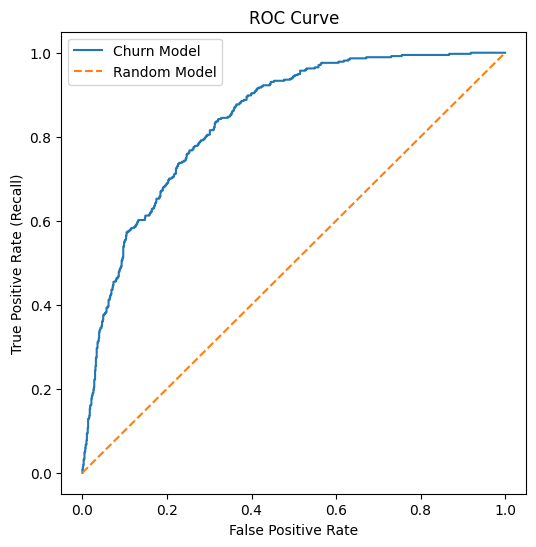

In [38]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="Churn Model")

plt.plot([0,1], [0,1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [39]:
auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", auc)

ROC AUC: 0.8416104781833683


In [40]:
y_prob = model.predict_proba(X_test)[:,1]

In [41]:
import numpy as np

In [42]:
J = tpr - fpr

ix = np.argmax(J)

best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)

Best Threshold: 0.45028575996108333


In [44]:
y_pred_optimal = (y_prob >= best_threshold).astype(int)

In [45]:
from sklearn.metrics import confusion_matrix, classification_report

cm_optimal = confusion_matrix(y_test, y_pred_optimal)

print(cm_optimal)

print(classification_report(y_test, y_pred_optimal))

[[881 154]
 [145 229]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1035
           1       0.60      0.61      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [47]:
#Start adding Random Forest model for comparison

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [48]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [49]:
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_prob)

In [50]:
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC AUC:", rf_auc)

Random Forest ROC AUC: 0.8206011521868299


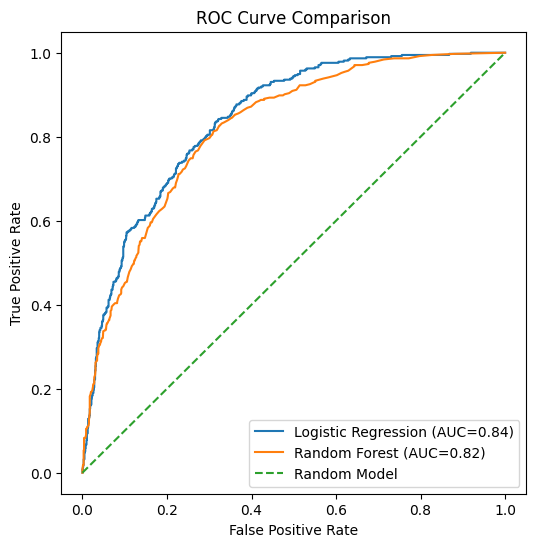

In [51]:
plt.figure(figsize=(6,6))

plt.plot(fpr,tpr, label=f"Logistic Regression (AUC={auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [52]:
importance = pd.Series(model.coef_[0], index=X_train.columns)
importance.sort_values(ascending=False)

internet_service_Fiber optic                0.967066
contract_Month-to-month                     0.698388
online_security_No                          0.386460
tech_support_No                             0.361478
multiple_lines_Yes                          0.302910
payment_method_Electronic check             0.290995
num_services                                0.287143
streaming_tv_Yes                            0.266365
streaming_movies_Yes                        0.266314
online_backup_No                            0.262965
paperless_billing_Yes                       0.213051
device_protection_No                        0.194750
senior_citizen                              0.147322
phone_service_Yes                           0.140646
dependents_No                               0.139839
device_protection_Yes                       0.045280
partner_Yes                                 0.039509
gender_Male                                 0.038424
gender_Female                               0.

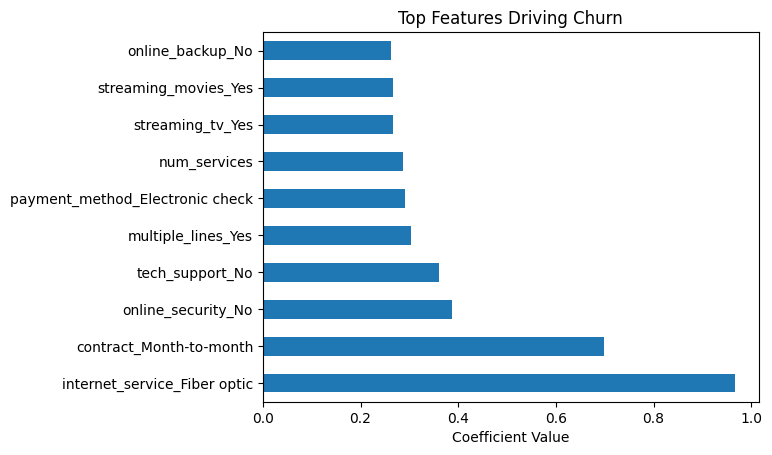

In [53]:
top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind="barh")

plt.title("Top Features Driving Churn")
plt.xlabel("Coefficient Value")

plt.show()

In [ ]:
from pathlib import Path
import joblib

Path("../../models").mkdir(parents=True, exist_ok=True)
joblib.dump(balanced_model, "../../models/churn_logistic_regression.pkl")

['../../models/churn_logistic_regression.pkl']